In [1]:
from astropy.table import Table, vstack, hstack
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl

from IPython.display import Image

from scipy.cluster.vq import whiten, kmeans, kmeans2
from sklearn.cluster import k_means

from astropy.io import fits

from color_gradient_functions import pogson_mag_from_flux

In [5]:
nsa = Table.read('/Users/nityaravi/Downloads/NSA_v1_0_1_VAGC_CMDJan2020_vflag-V2-VF.fits')

In [6]:
nsa[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,flag3727,t3,Z12logOH,Zerr,N12logNH,NHerr,logNO,NOerr,Ne12logNeH,NeHerr,logNeO,NeOerr,Z_N2O2,vorvol,V2_depth,vflag_V2,vflag_VF,u_r_err,g_r_err,NUV_r_err,CMD_class,MPA_index,sSFR_err,SFR_err
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float32,float32,float32,int64,int64,float64,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1

In [4]:
nsa['NUV_i'] = nsa['ELPETRO_ABSMAG'][:,1] - nsa['ELPETRO_ABSMAG'][:,5]

In [5]:
nsa['SN_NUV_r'] = np.abs(nsa['ELPETRO_ABSMAG'][:,1]*np.sqrt(nsa['ELPETRO_AMIVAR'][:,1]))

In [6]:
nsa_lowz = nsa['Z'] <= 0.06
nsa_medz = np.logical_and(nsa['Z'] > 0.06, nsa['Z'] <= 0.08)
nsa_highz = nsa['Z'] > 0.08

In [7]:
nsa_good_nuv = nsa['SN_NUV_r'] > 5

(array([116286.,    406.,    317.,    303.,    285.,    330.,    301.,
           290.,    278.,    268.,    244.,    264.,    299.,    245.,
           281.,    268.,    264.,    260.,    267.,    302.,    289.,
           282.,    254.,    269.,    289.,    276.,    286.,    258.,
           271.,    283.,    255.,    294.,    265.,    296.,    282.,
           253.,    295.,    283.,    264.,    274.,    267.,    285.,
           290.,    289.,    276.,    293.,    304.,    289.,    287.,
           297.,    290.,    290.,    270.,    264.,    285.,    290.,
           281.,    290.,    289.,    279.,    282.,    274.,    322.,
           294.,    288.,    328.,    267.,    298.,    269.,    251.,
           312.,    295.,    259.,    256.,    261.,    296.,    253.,
           270.,    266.,    298.,    293.,    278.,    260.,    265.,
           278.,    291.,    288.,    295.,    318.,    277.,    280.,
           290.,    303.,    303.,    274.,    276.,    251.,    269.,
      

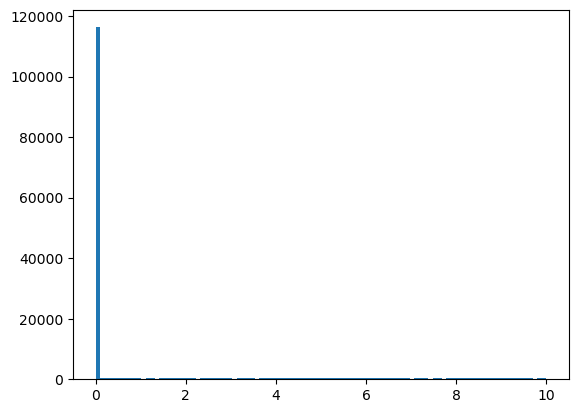

In [69]:
plt.hist(nsa['SN_NUV_r'], bins=np.linspace(0,10,100))

(array([  75.,   13.,   14.,   16.,   13.,   29.,   20.,   36.,   34.,
          44.,   51.,   60.,   52.,   72.,  115.,  132.,  157.,  217.,
         370.,  746., 1156., 1374., 1501., 1414., 1217.,  972.,  830.,
         663.,  613.,  478.,  359.,  335.,  250.,  196.,  130.,   98.,
          74.,   80.,   56.]),
 array([ 0.        ,  0.30769231,  0.61538462,  0.92307692,  1.23076923,
         1.53846154,  1.84615385,  2.15384615,  2.46153846,  2.76923077,
         3.07692308,  3.38461538,  3.69230769,  4.        ,  4.30769231,
         4.61538462,  4.92307692,  5.23076923,  5.53846154,  5.84615385,
         6.15384615,  6.46153846,  6.76923077,  7.07692308,  7.38461538,
         7.69230769,  8.        ,  8.30769231,  8.61538462,  8.92307692,
         9.23076923,  9.53846154,  9.84615385, 10.15384615, 10.46153846,
        10.76923077, 11.07692308, 11.38461538, 11.69230769, 12.        ]),
 <BarContainer object of 39 artists>)

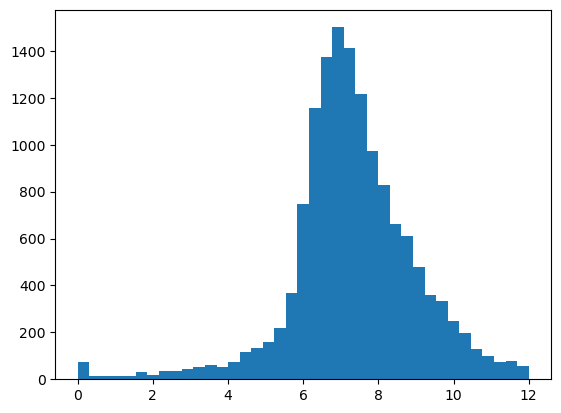

In [10]:
plt.hist(nsa['NUV_r'][~nsa_good_nuv], bins=np.linspace(0,12,40))

(array([1.54408e+05, 1.15829e+05, 6.47150e+04, 3.69280e+04, 2.14670e+04,
        1.08810e+04, 3.78300e+03, 7.08000e+02, 9.00000e+01, 6.00000e+00]),
 array([4.97268396e-04, 6.76932484e-02, 1.34889230e-01, 2.02085212e-01,
        2.69281209e-01, 3.36477190e-01, 4.03673172e-01, 4.70869154e-01,
        5.38065135e-01, 6.05261087e-01, 6.72457099e-01]),
 <BarContainer object of 10 artists>)

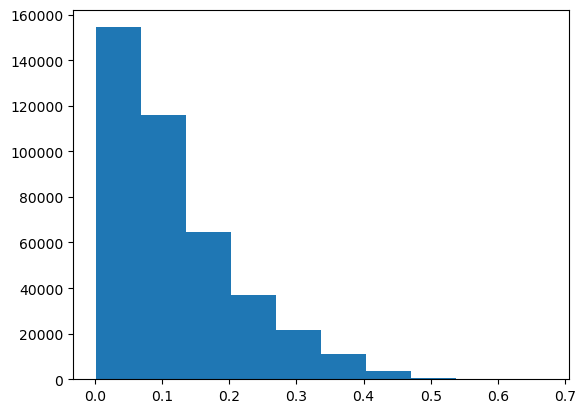

In [13]:
plt.hist(nsa['NUV_r_err'])

Text(0.5, 0, 'NUV - r')

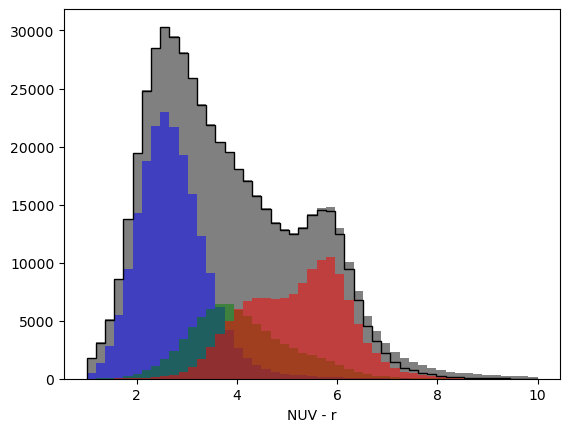

In [12]:
plt.hist(nsa['NUV_r'], bins=np.linspace(1,10, 50), color='grey', density=0)
plt.hist(nsa['NUV_r'][nsa_good_nuv], bins=np.linspace(1,10, 50), density=0, histtype='step', color='k')
plt.hist(nsa['NUV_r'][(nsa['CMD_class'] == 1) & nsa_good_nuv], bins=np.linspace(1,10, 50), color='b', alpha=0.5, density=0)
plt.hist(nsa['NUV_r'][(nsa['CMD_class'] == 2) & nsa_good_nuv], bins=np.linspace(1,10, 50), color='g', alpha=0.5, density=0)
plt.hist(nsa['NUV_r'][(nsa['CMD_class'] == 3) & nsa_good_nuv], bins=np.linspace(1,10, 50), color='r', alpha=0.5, density=0)

# plt.hist(nsa['NUV_r'][nsa['ELPETRO_ABSMAG'][:,1] < nsa['ELPETRO_ABSMAG'][:,2]], histtype='step', color='k', bins=np.linspace(1,10,50), density=1)
plt.xlabel('NUV - r')

Text(0.5, 0, 'NUV - r')

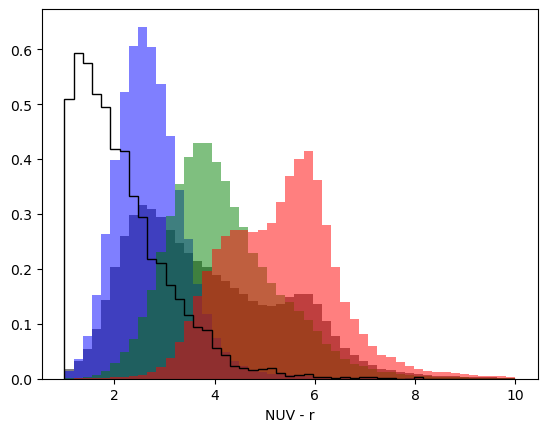

In [64]:
plt.hist(nsa['NUV_r'], bins=np.linspace(1,10, 50), color='grey', density=1)
plt.hist(nsa['NUV_r'][nsa['CMD_class'] == 1], bins=np.linspace(1,10, 50), color='b', alpha=0.5, density=1)
plt.hist(nsa['NUV_r'][nsa['CMD_class'] == 2], bins=np.linspace(1,10, 50), color='g', alpha=0.5, density=1)
plt.hist(nsa['NUV_r'][nsa['CMD_class'] == 3], bins=np.linspace(1,10, 50), color='r', alpha=0.5, density=1)

# plt.hist(nsa['NUV_r'][nsa['ELPETRO_ABSMAG'][:,1] < nsa['ELPETRO_ABSMAG'][:,2]], histtype='step', color='k', bins=np.linspace(1,10,50), density=1)
plt.xlabel('NUV - r')

Text(0.5, 0, 'NUV - r for z< 0.06')

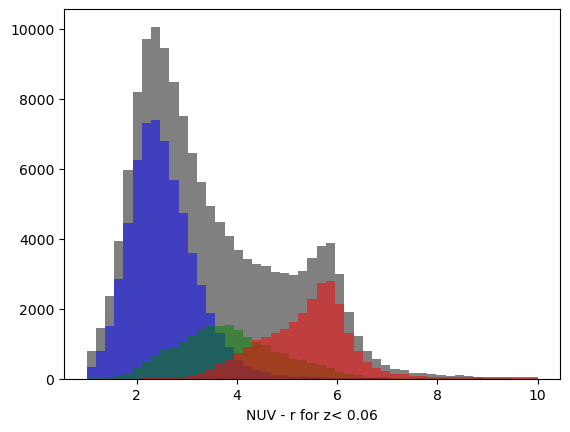

In [5]:
plt.hist(nsa_lowz['NUV_r'], bins=np.linspace(1,10, 50), color='grey')
plt.hist(nsa_lowz['NUV_r'][nsa_lowz['CMD_class'] == 1], bins=np.linspace(1,10, 50), color='b', alpha=0.5)
plt.hist(nsa_lowz['NUV_r'][nsa_lowz['CMD_class'] == 2], bins=np.linspace(1,10, 50), color='g', alpha=0.5)
plt.hist(nsa_lowz['NUV_r'][nsa_lowz['CMD_class'] == 3], bins=np.linspace(1,10, 50), color='r', alpha=0.5)
plt.xlabel('NUV - r for z< 0.06')

Text(0.5, 0, 'NUV - r for medium z')

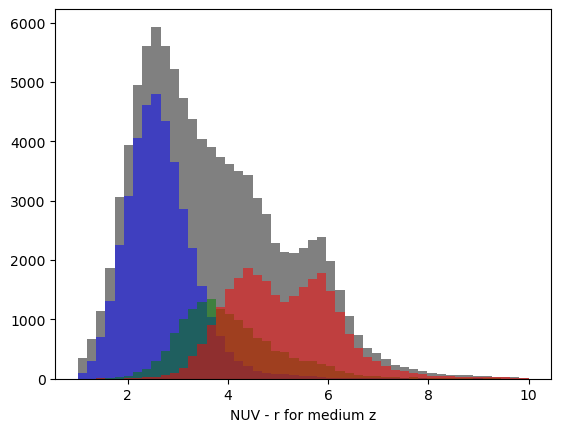

In [12]:
plt.hist(nsa_medz['NUV_r'], bins=np.linspace(1,10, 50), color='grey')
plt.hist(nsa_medz['NUV_r'][nsa_medz['CMD_class'] == 1], bins=np.linspace(1,10, 50), color='b', alpha=0.5)
plt.hist(nsa_medz['NUV_r'][nsa_medz['CMD_class'] == 2], bins=np.linspace(1,10, 50), color='g', alpha=0.5)
plt.hist(nsa_medz['NUV_r'][nsa_medz['CMD_class'] == 3], bins=np.linspace(1,10, 50), color='r', alpha=0.5)
plt.xlabel('NUV - r for medium z')

Text(0.5, 0, 'NUV - r for z> 0.08')

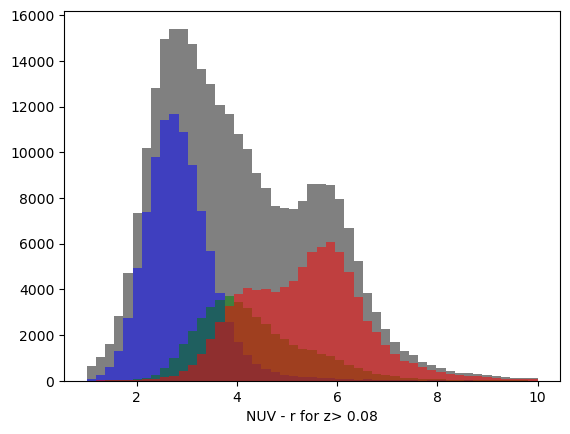

In [14]:
plt.hist(nsa_highz['NUV_r'], bins=np.linspace(1,10, 50), color='grey')
plt.hist(nsa_highz['NUV_r'][nsa_highz['CMD_class'] == 1], bins=np.linspace(1,10, 50), color='b', alpha=0.5)
plt.hist(nsa_highz['NUV_r'][nsa_highz['CMD_class'] == 2], bins=np.linspace(1,10, 50), color='g', alpha=0.5)
plt.hist(nsa_highz['NUV_r'][nsa_highz['CMD_class'] == 3], bins=np.linspace(1,10, 50), color='r', alpha=0.5)
plt.xlabel('NUV - r for z> 0.08')

Text(0.5, 0, 'NUV - i for z> 0.06')

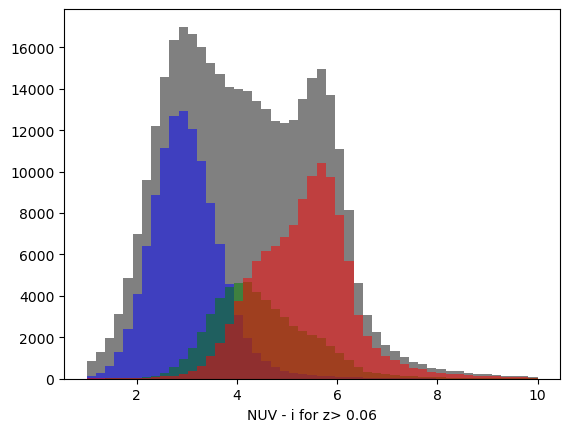

In [15]:
plt.hist(nsa_highz['NUV_i'], bins=np.linspace(1,10, 50), color='grey')
plt.hist(nsa_highz['NUV_i'][nsa_highz['CMD_class'] == 1], bins=np.linspace(1,10, 50), color='b', alpha=0.5)
plt.hist(nsa_highz['NUV_i'][nsa_highz['CMD_class'] == 2], bins=np.linspace(1,10, 50), color='g', alpha=0.5)
plt.hist(nsa_highz['NUV_i'][nsa_highz['CMD_class'] == 3], bins=np.linspace(1,10, 50), color='r', alpha=0.5)
plt.xlabel('NUV - i for z> 0.06')

Text(0.5, 0, 'u - r for medium z')

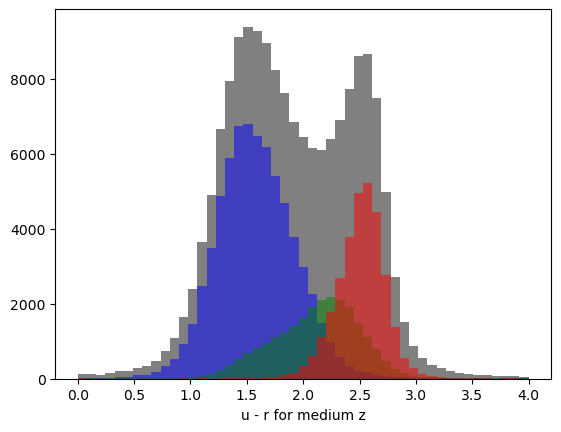

In [19]:
plt.hist(nsa_lowz['u_r'], bins=np.linspace(0,4, 50), color='grey')
plt.hist(nsa_lowz['u_r'][nsa_lowz['CMD_class'] == 1], bins=np.linspace(0,4, 50), color='b', alpha=0.5)
plt.hist(nsa_lowz['u_r'][nsa_lowz['CMD_class'] == 2], bins=np.linspace(0,4, 50), color='g', alpha=0.5)
plt.hist(nsa_lowz['u_r'][nsa_lowz['CMD_class'] == 3], bins=np.linspace(0,4, 50), color='r', alpha=0.5)
plt.xlabel('u - r for medium z')

Text(0.5, 0, 'u - r for medium z')

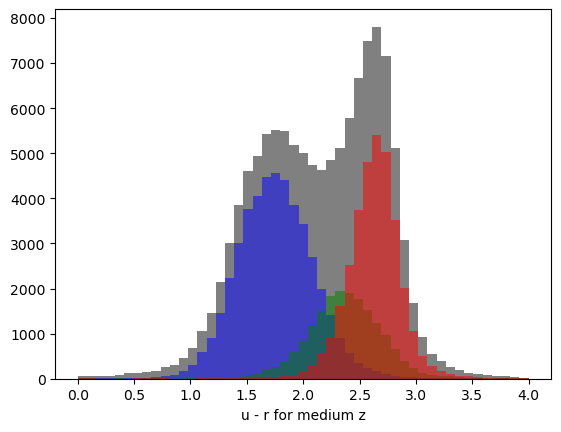

In [18]:
plt.hist(nsa_medz['u_r'], bins=np.linspace(0,4, 50), color='grey')
plt.hist(nsa_medz['u_r'][nsa_medz['CMD_class'] == 1], bins=np.linspace(0,4, 50), color='b', alpha=0.5)
plt.hist(nsa_medz['u_r'][nsa_medz['CMD_class'] == 2], bins=np.linspace(0,4, 50), color='g', alpha=0.5)
plt.hist(nsa_medz['u_r'][nsa_medz['CMD_class'] == 3], bins=np.linspace(0,4, 50), color='r', alpha=0.5)
plt.xlabel('u - r for medium z')

Text(0.5, 0, 'u - r for medium z')

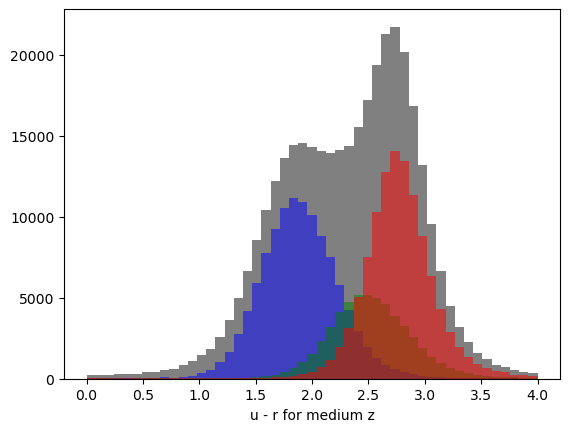

In [20]:
plt.hist(nsa_highz['u_r'], bins=np.linspace(0,4, 50), color='grey')
plt.hist(nsa_highz['u_r'][nsa_highz['CMD_class'] == 1], bins=np.linspace(0,4, 50), color='b', alpha=0.5)
plt.hist(nsa_highz['u_r'][nsa_highz['CMD_class'] == 2], bins=np.linspace(0,4, 50), color='g', alpha=0.5)
plt.hist(nsa_highz['u_r'][nsa_highz['CMD_class'] == 3], bins=np.linspace(0,4, 50), color='r', alpha=0.5)
plt.xlabel('u - r for medium z')

In [22]:
nsa[nsa['index'] == 36857]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,flag3727,t3,Z12logOH,Zerr,N12logNH,NHerr,logNO,NOerr,Ne12logNeH,NeHerr,logNeO,NeOerr,Z_N2O2,vorvol,V2_depth,vflag_V2,vflag_VF,u_r_err,g_r_err,NUV_r_err,CMD_class,MPA_index,sSFR_err,SFR_err,NUV_i
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float32,float32,float32,int64,int64,float64,float64,float32
J160643.89+001545.0,16h/p00/J160643.89+001545.0,241.68292780742848,0.26253239929178485,23160,-1,-1,-1,-1,-1,17.690191,0.062052183,sdss,0.06628832,5396,6,23,301,1230.1896,712.22986,23044,0.061927564,-4.431995 .. 469.2546,0.0024907277 .. 0.0014762671,1,0.31170648 .. 520.2945,-12.680651 .. -20.651512,0.0 .. 275.76132,1.8639767 .. 0.33254784,0.0031453734 .. 0.029847555,5.809546e-06 .. 6.9443947e-12,0.003936811 .. 1.2492663,1.306687e-07,0.04936836,0.023839992,16065900000.0,135.34967041015625,163.57752990722656,10 .. 11,-0.021993143 .. 0.0,19.877068 .. 0.0,0.04681501 .. 0.009374143,0.0023710253 .. 0.42605275,0.9104478 .. 0.40237123,1.449682 .. 44.36978,10.886925 .. 316.96182,0.0010744511 .. 0.000112643196,-0.026181368 .. 74.0374,4.848867 .. 0.0791902,0.86777866,1.853302,0.89151675,8.817505,-0.7961751 .. 358.41766,0.07718563 .. 0.003365831,6.0,0.80490756,8.695709,-10.725433 .. -2.7150517,-5.1693397 .. -3.5615525,0 .. 0,0,35,v2_1_14,0.22341923 .. 258.39,42.855865,17.01767,36.96857,5.6436396,344,587,51693,241.68291127101318,0.26252387100188473,0.0,sdss,legacy,good,145,241.6829,0.26253345,0.89151675,8.817505,100.02315,0.5048933,5.8102503,2.6825414,8.987271,5.8102503,4.3272333 .. 218.49963,0.06158426 .. 0.0026288591,8.468931 .. 2.3413346,10.482515 .. 7.5534163,1.0015097,1.0764519

(0.0, 3.0)

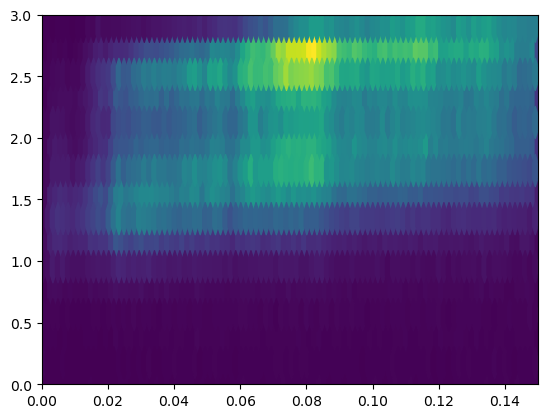

In [25]:
plt.hexbin(nsa['Z'], nsa['u_r'])
plt.xlim(0,0.15)
plt.ylim(0,3)

(0.0, 4.0)

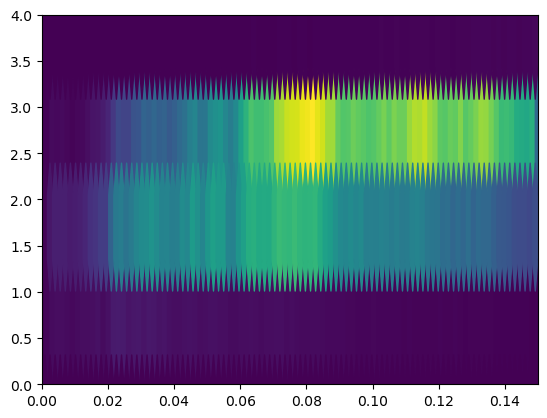

In [27]:
plt.hexbin(nsa['Z'], nsa['u_r_KIAS'])
plt.xlim(0,0.15)
plt.ylim(0,4)

(array([ 2019.,  3205.,  2632.,  4005.,  6687.,  9584., 11931., 13387.,
        14430., 13854., 13725., 15391., 15239., 17091., 16049., 17137.,
        21153., 20759., 23338., 25090., 25522., 26485., 23437., 19907.,
        20163., 19006., 19217., 19877., 19883., 21081., 20405., 18411.,
        18331., 18201., 19470., 18757., 16426., 14801., 15026.]),
 array([0.        , 0.00384615, 0.00769231, 0.01153846, 0.01538462,
        0.01923077, 0.02307692, 0.02692308, 0.03076923, 0.03461538,
        0.03846154, 0.04230769, 0.04615385, 0.05      , 0.05384615,
        0.05769231, 0.06153846, 0.06538462, 0.06923077, 0.07307692,
        0.07692308, 0.08076923, 0.08461538, 0.08846154, 0.09230769,
        0.09615385, 0.1       , 0.10384615, 0.10769231, 0.11153846,
        0.11538462, 0.11923077, 0.12307692, 0.12692308, 0.13076923,
        0.13461538, 0.13846154, 0.14230769, 0.14615385, 0.15      ]),
 <BarContainer object of 39 artists>)

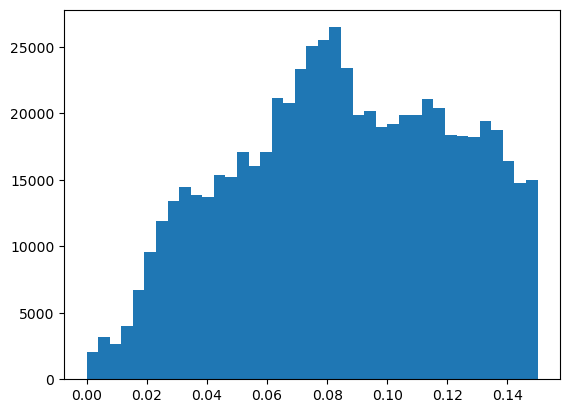

In [28]:
plt.hist(nsa['Z'], bins=np.linspace(0,0.15,40))

(10.0, 25.0)

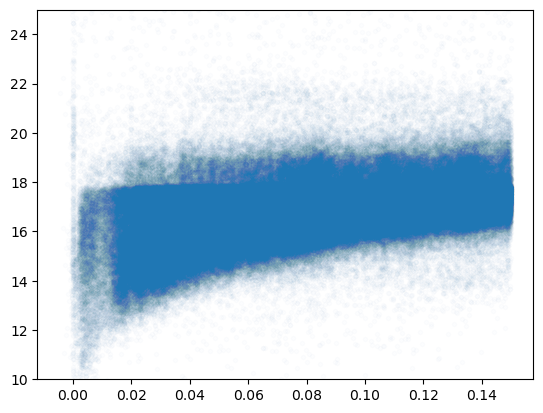

In [40]:
plt.scatter(nsa['Z'], pogson_mag_from_flux(nsa['ELPETRO_FLUX'][:,4]), marker='.', alpha=0.01)
plt.ylim(10,25)

(-10.0, -24.0)

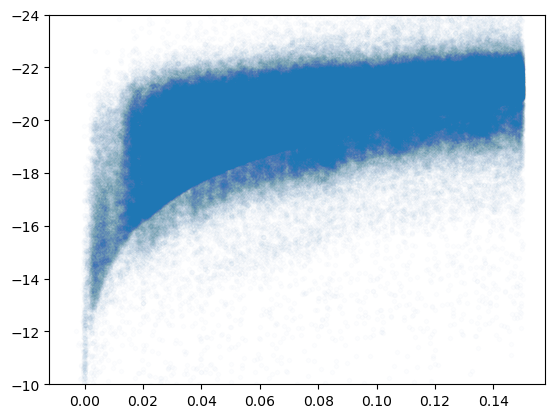

In [43]:
plt.scatter(nsa['Z'], nsa['ELPETRO_ABSMAG'][:,4], marker='.', alpha=0.01)
plt.ylim(-10, -24)

In [12]:
nsa[nsa['index'] == 36857]['ELPETRO_TH90_R']

8.987271


In [58]:
nsa[nsa['CMD_class']==1]['ELPETRO_ABSMAG'][0]

masked_array(data=[-16.859264373779297, -16.784395217895508,
                   -18.210168838500977, -19.47823715209961,
                   -19.97614288330078, -20.180389404296875,
                   -20.325403213500977],
             mask=[False, False, False, False, False, False, False],
       fill_value=nan,
            dtype='>f4')

In [55]:
nsa[nsa['CMD_class']==3]['ELPETRO_ABSMAG'][0]

masked_array(data=[-14.501482009887695, -16.227293014526367,
                   -19.0172119140625, -20.747156143188477,
                   -21.559162139892578, -21.906070709228516,
                   -22.221017837524414],
             mask=[False, False, False, False, False, False, False],
       fill_value=nan,
            dtype='>f4')

In [25]:
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord
import astropy.units as u
from time import time

In [13]:
10/3600

0.002777777777777778

In [21]:
obs_table = Observations.query_criteria(coordinates="241.6829 0.26253",
                                        # radius="1 arcsec",
                                        # filters=["*UV"],
                                        obs_collection="GALEX")

In [22]:
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,objID1,distance
str7,str5,str3,str5,str3,str3,str2,str28,str1,str19,float64,float64,str5,str1,int64,float64,float64,float64,str2,float64,float64,str1,float64,str1,str3,int64,str43,str154,str148,str6,bool,float64,str5,str5,float64,float64,str5,float64
science,GALEX,AIS,GALEX,AIS,FUV,UV,AIS_338_1_92,--,6382808172037406720,241.674753328375,0.332354196823386,image,--,2,54281.54887731481,54281.55011574074,107.0,UV,134.0,180.6,--,55478.07409721,--,AIS,--,CIRCLE ICRS 241.67475333 0.33235420 0.625,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50338-AIS_338/d/01-main/0001-img/07-try/qa/AIS_338_sg92-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50338-AIS_338/d/01-main/0001-img/07-try/AIS_338_sg92-xd-mcat.fits.gz,PUBLIC,--,5885.0,33754,59526,134.0,180.6,59526,0.0
science,GALEX,MIS,GALEX,MIS,NUV,UV,MISGCSN2_22274_0339_css38150,--,6464075176685338624,241.67057222797598,0.339560876915909,image,--,2,55370.02664351852,55370.032800925925,532.25,UV,169.3,300.7,--,56222.83873838,--,MIS,--,CIRCLE ICRS 241.67057223 0.33956088 0.625,http://galex.stsci.edu/data/GR7/pipe/02-vsn/52648-MISGCSN2_22274_0339_css38150/d/01-main/0001-img/07-try/qa/MISGCSN2_22274_0339_css38150-xd-int_2color.jpg,http://galex.stsci.edu/data/GR7/pipe/02-vsn/52648-MISGCSN2_22274_0339_css38150/d/01-main/0001-img/07-try/MISGCSN2_22274_0339_css38150-nd-exp.fits.gz,PUBLIC,--,5885.0,44361,78464,169.3,300.7,78464,0.0
science,GALEX,AIS,GALEX,AIS,NUV,UV,AIS_338_1_92,--,6382808172037406720,241.674753328375,0.332354196823386,image,--,2,54281.54887731481,54281.55011574074,107.0,UV,169.3,300.7,--,55478.07409721,--,AIS,--,CIRCLE ICRS 241.67475333 0.33235420 0.625,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50338-AIS_338/d/01-main/0001-img/07-try/qa/AIS_338_sg92-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50338-AIS_338/d/01-main/0001-img/07-try/AIS_338_sg92-nd-exp.fits.gz,PUBLIC,--,5885.0,33754,59525,169.3,300.7,59525,0.0


In [24]:
obs = SkyCoord(ra=nsa['RA'][:2]*u.degree,
               dec=nsa['DEC'][:2]*u.degree,
              )

In [27]:
start_time = time()

for i in range(2):
    obs_table = Observations.query_criteria(coordinates=obs[i],
                                        radius=10*u.arcsec,
                                        # filters=["*UV"],
                                        obs_collection="GALEX")
print(time() - start_time)

10.265359163284302


In [28]:
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,objID1,distance
str7,str5,str3,str5,str3,str3,str2,str19,str1,str19,float64,float64,str5,str1,int64,float64,float64,float64,str2,float64,float64,str1,float64,str1,str3,int64,str43,str136,str130,str6,bool,float64,str5,str5,float64,float64,str5,float64
science,GALEX,MIS,GALEX,MIS,NUV,UV,MISWZN09_24375_0336,--,2925934719432392704,146.53560120517602,-1.35129428862366,image,--,2,54846.58663194445,54846.605995370366,1673.0,UV,169.3,300.7,--,55275.15584485,--,MIS,--,CIRCLE ICRS 146.53560121 -1.35129429 0.625,http://galex.stsci.edu/data/GR6/pipe/01-vsn/17624-MISWZN09_24375_0336/d/01-main/0001-img/07-try/qa/MISWZN09_24375_0336-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/01-vsn/17624-MISWZN09_24375_0336/d/01-main/0001-img/07-try/MISWZN09_24375_0336-nd-int.fits.gz,PUBLIC,--,5885.0,2983,5471,169.3,300.7,5471,0.0
science,GALEX,MIS,GALEX,MIS,FUV,UV,MISWZN09_24375_0336,--,2925934719432392704,146.53560120517602,-1.35129428862366,image,--,2,54846.58663194445,54846.605995370366,1673.0,UV,134.0,180.6,--,55275.15584485,--,MIS,--,CIRCLE ICRS 146.53560121 -1.35129429 0.625,http://galex.stsci.edu/data/GR6/pipe/01-vsn/17624-MISWZN09_24375_0336/d/01-main/0001-img/07-try/qa/MISWZN09_24375_0336-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/01-vsn/17624-MISWZN09_24375_0336/d/01-main/0001-img/07-try/MISWZN09_24375_0336-fd-cnt.fits.gz,PUBLIC,--,5885.0,2983,5472,134.0,180.6,5472,0.0
science,GALEX,MIS,GALEX,MIS,NUV,UV,MISDR1_24341_0266,--,2411539199493668864,147.06665651598496,-0.505077698873353,image,--,2,54156.235625,54156.31905092593,2327.0,UV,169.3,300.7,--,55274.93010405,--,MIS,--,CIRCLE ICRS 147.06665652 -0.50507770 0.625,http://galex.stsci.edu/data/GR6/pipe/01-vsn/03004-MISDR1_24341_0266/d/01-main/0001-img/07-try/qa/MISDR1_24341_0266-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/01-vsn/03004-MISDR1_24341_0266/d/01-main/0001-img/07-try/MISDR1_24341_0266-nd-exp.fits.gz,PUBLIC,--,5885.0,14,27,169.3,300.7,27,0.0
science,GALEX,AIS,GALEX,AIS,NUV,UV,AIS_335_1_96,--,6382702623216107520,146.538651380134,-1.35031131539118,image,--,2,53081.640601851854,53081.64202546296,123.0,UV,169.3,300.7,--,55369.85403922,--,AIS,--,CIRCLE ICRS 146.53865138 -1.35031132 0.625,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50335-AIS_335/d/01-main/0001-img/07-try/qa/AIS_335_sg96-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50335-AIS_335/d/01-main/0001-img/07-try/AIS_335_sg96-nd-int.fits.gz,PUBLIC,--,5885.0,33505,59027,169.3,300.7,59027,0.0
science,GALEX,AIS,GALEX,AIS,FUV,UV,AIS_335_1_92,--,6382702618921140224,147.05464650697104,-0.506591659938278,image,--,2,53081.65327546296,53081.6547337963,126.0,UV,134.0,180.6,--,55369.85734949,--,AIS,--,CIRCLE ICRS 147.05464651 -0.50659166 0.625,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50335-AIS_335/d/01-main/0001-img/07-try/qa/AIS_335_sg92-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50335-AIS_335/d/01-main/0001-img/07-try/AIS_335_sg92-fd-exp.fits.gz,PUBLIC,--,5885.0,33501,59020,134.0,180.6,59020,0.0
science,GALEX,AIS,GALEX,AIS,FUV,UV,AIS_335_1_96,--,6382702623216107520,146.538651380134,-1.35031131539118,image,--,2,53081.640601851854,53081.64202546296,123.0,UV,134.0,180.6,--,55369.85403922,--,AIS,--,CIRCLE ICRS 146.53865138 -1.35031132 0.625,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50335-AIS_335/d/01-main/0001-img/07-try/qa/AIS_335_sg96-xd-int_2color.jpg,http://galex.stsci.edu/data/GR6/pipe/02-vsn/50335-AIS_335/d/01-main/0001-img/07-try/AIS_335_sg96-fd-exp.fits.gz,PUBLIC,--,5885.0,33505,59028,134.0,180.6,59028,0.0
science,GALEX,AIS,GALEX,AIS,NUV,UV,AIS_335_1_92,--,6382702618921140224,147.05464650697104,-0.

In [29]:
hdu = fits.open('/Users/nityaravi/Downloads/tab_2335_1_II_335_galex_ais.moc.fits')


In [34]:
hdu.info()

Filename: /Users/nityaravi/Downloads/tab_2335_1_II_335_galex_ais.moc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU     15   563400R x 1C   [1J]   


In [35]:
hdu[1].data[:5]

FITS_rec([(3211,), (3214,), (4129,), (4225,), (4227,)],
         dtype=(numpy.record, [('NPIX', '>i4')]))

In [37]:
len(nsa[nsa['CMD_class'] > 0])

505076